# Cross-Validation

Evaluate model generalization via 80/20 train/test cross-validation
across the fusion-regularization grid.

**Outline**
1. Load training functional scores and pipeline config
2. Split data into train (80%) and test (20%) sets per replicate
3. Fit models on training data across the fusionreg grid
4. Evaluate validation loss on held-out test data
5. Visualize training vs validation loss

In [1]:
import warnings

warnings.filterwarnings("ignore")

import os
import sys

sys.path.insert(0, "notebooks")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import multidms
from multidms.model_collection import ModelCollection, fit_models
from multidms.utils import explode_params_dict

from _common import load_config, build_fit_params

In [2]:
config_path = "config/config.yaml"
output_dir = None

In [3]:
# Parameters
config_path = "config/config.yaml"
output_dir = "results-prod-225-spike-data-prep-improvements"


In [4]:
config = load_config(config_path)
spike = config["spike"]
fit_config = spike["fitting"]
reference = spike["reference"]

seed = config["seed"]
train_frac = config["train_frac"]
condition_titles = spike["condition_titles"]

if output_dir is None:
    output_dir = spike.get("output_dir", "results")
os.makedirs(output_dir, exist_ok=True)

## Load training functional scores

In [5]:
func_score_df = pd.read_csv(
    os.path.join(output_dir, "training_functional_scores.csv")
).fillna({"aa_substitutions": ""})
print(f"Loaded {len(func_score_df):,} variants")

Loaded 303,007 variants


## Train/test split

Split functional scores 80/20 per replicate. Wildtype variants are kept
in the training set.

In [6]:
train_datasets = []
test_data = {}

for rep_num, df_rep in func_score_df.groupby("replicate"):
    # Aggregate per (condition, aa_substitutions)
    df_agg = (
        df_rep.groupby(["condition", "aa_substitutions"], dropna=False)
        .agg({"func_score": "mean"})
        .reset_index()
    )

    wt_mask = df_agg["aa_substitutions"].str.strip() == ""
    wt_rows = df_agg[wt_mask]
    non_wt_rows = df_agg[~wt_mask].sample(frac=1, random_state=seed)

    n_train = int(len(non_wt_rows) * train_frac)
    train_split = pd.concat([wt_rows, non_wt_rows.iloc[:n_train]])
    test_split = non_wt_rows.iloc[n_train:]

    name = f"rep_{rep_num}"
    train_datasets.append(
        multidms.Data(
            train_split,
            reference=reference,
            alphabet=multidms.AAS_WITHSTOP_WITHGAP,
            assert_site_integrity=False,
            verbose=False,
            name=name,
        )
    )
    test_data[name] = test_split
    print(f"{name}: {len(train_split):,} train, {len(test_split):,} test")

rep_1: 125,836 train, 31,459 test


rep_2: 116,570 train, 29,142 test


## Fit CV models

In [7]:
cv_fitting_params = build_fit_params(fit_config, train_datasets)

n_models = len(explode_params_dict(cv_fitting_params))
cfg_n_processes = fit_config.get("n_processes")

if cfg_n_processes is None:
    n_processes = min(os.cpu_count() // 2, n_models)
else:
    n_processes = min(int(cfg_n_processes), n_models)
n_processes = max(n_processes, 1)

print(f"Fitting {n_models} CV models with n_processes={n_processes}")

n_fit, n_failed, fit_collection_cv = fit_models(
    cv_fitting_params, n_processes=n_processes
)

for col in fit_collection_cv.columns:
    if fit_collection_cv[col].apply(lambda x: isinstance(x, dict)).any():
        fit_collection_cv[col] = fit_collection_cv[col].apply(str)

print(f"CV: fit {n_fit} models, {n_failed} failed")

Fitting 14 CV models with n_processes=14


CV: fit 14 models, 0 failed


## Evaluate validation loss

In [8]:
mc_cv = ModelCollection(fit_collection_cv)

# Filter test variants to those with known mutations only
filtered_test = {}
for name, test_df in test_data.items():
    model = (
        mc_cv.fit_models.query(f"dataset_name == '{name}'")
        .iloc[0]
        .model
    )
    known_muts = set(model.data.mutations)

    def all_muts_known(subs):
        if pd.isna(subs) or subs.strip() == "":
            return True
        return all(m in known_muts for m in subs.split())

    mask = test_df["aa_substitutions"].apply(all_muts_known)
    filtered_test[name] = test_df[mask]
    n_dropped = (~mask).sum()
    if n_dropped > 0:
        print(f"{name}: dropped {n_dropped}/{len(test_df)} test variants with unseen mutations")

mc_cv.add_eval_loss(filtered_test, overwrite=True)

rep_1: dropped 6062/31459 test variants with unseen mutations
rep_2: dropped 5413/29142 test variants with unseen mutations


## Visualize CV loss

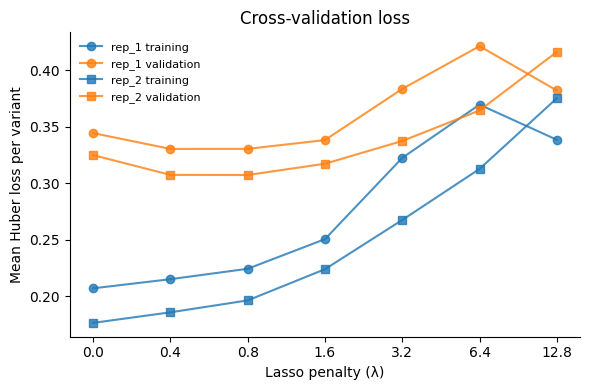

In [9]:
cv_data = mc_cv.fit_models.copy()
cv_data = (
    cv_data.melt(
        id_vars=["fusionreg", "dataset_name"],
        value_vars=["total_loss_training", "total_loss_validation"],
        var_name="dataset",
        value_name="loss",
    )
    .assign(dataset=lambda x: x["dataset"].str.replace("total_loss_", ""))
)

# Normalize loss by sample count
n_samples = {}
for d in train_datasets:
    n_train = sum(
        len(d.variants_df.query(f"condition == '{c}'"))
        for c in d.conditions
    )
    n_samples[(d.name, "training")] = n_train
for name, test_df in filtered_test.items():
    n_test = sum(
        len(test_df.query(f"condition == '{c}'"))
        for c in test_df["condition"].unique()
    )
    n_samples[(name, "validation")] = n_test

cv_data["n_samples"] = cv_data.apply(
    lambda row: n_samples.get((row["dataset_name"], row["dataset"]), 1),
    axis=1,
)
cv_data["mean_loss"] = cv_data["loss"] / cv_data["n_samples"]
cv_data["fusionreg_cat"] = cv_data["fusionreg"].astype(str)

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
for (rep, ds), grp in cv_data.groupby(["dataset_name", "dataset"]):
    grp = grp.sort_values("fusionreg")
    marker = "o" if "rep_1" in rep else "s"
    color = "tab:blue" if ds == "training" else "tab:orange"
    ax.plot(
        grp["fusionreg_cat"], grp["mean_loss"],
        marker=marker, color=color, alpha=0.8,
        label=f"{rep} {ds}",
    )

ax.set_xlabel("Lasso penalty (\u03bb)")
ax.set_ylabel("Mean Huber loss per variant")
ax.set_title("Cross-validation loss")
ax.legend(fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Save

In [10]:
cv_data.to_csv(
    os.path.join(output_dir, "cross_validation_loss.csv"), index=False
)
print(f"Saved cross_validation_loss.csv ({len(cv_data)} rows)")

Saved cross_validation_loss.csv (28 rows)
